<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
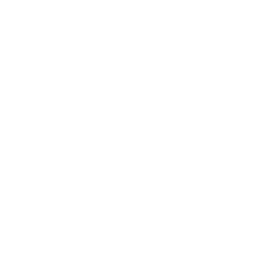
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">化学反应器异常诊断</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 识别导致反应器 T² 超限的驱动变量（异常事件期间）&nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## 摘要

一台连续搅拌釜式反应器（CSTR）因冷却剂供应劣化而陷入热态异常。在正常运行状态下，冷却剂流量、反应器温度与夹套温度沿单一过程负荷轴共同变化。我们基于 100 条正常运行观测数据构建了一个三分量 MVP 模型，然后用 `PROC MVPDIAGNOSE` 对 100 条异常事件观测数据进行评分。将 Hotelling *T*² 统计量分解为各变量的贡献度后，锁定了热耦合三变量组——`jacket_temp`、`coolant_flow` 与 `reactor_temp`——为驱动超限的变量，直接将运维人员的注意力指向冷却剂子系统。


## 数据来源

| 数据集 | 角色 | 观测数 |
|---|---|---|
| `reactor_normal` | 用于 MVP 模型的正常运行训练数据 | 100 |
| `reactor_upset` | 针对模型评分的异常事件观测数据 | 100 |

六个测量变量分别为 `reactor_temp`（℃）、`coolant_flow`（L/min）、`jacket_temp`（℃）、`feed_conc`（g/L）以及 `pressure`（bar）。两个数据集均由共享的潜在*过程负荷*模拟而来，因此正常数据具有与真实 CSTR 相同的相关结构；异常事件则注入了一次冷却剂供应损失，打破了这种结构。


## 步骤 1 — 训练正常运行状态下的 MVP 模型

正常运行受一个潜在过程负荷支配：负荷升高会拉低冷却剂流量，同时推高反应器与夹套温度。`PROC MVPMODEL` 从 100 条正常观测数据中提取三个主成分，并通过 `OUTMODEL=` 持久化保存，以便诊断步骤可以对照同一参考模型评分新数据。


In [1]:
数据 reactor_normal;
  调用 streaminit(7);
  循环 t = 1 到 100;
    load = rand('normal', 0, 1);                 /* 潜在过程负荷 */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    输出;
  结束;
运行;

过程 mvpmodel 数据=reactor_normal outmodel=reactor_model;
  变量 reactor_temp coolant_flow jacket_temp feed_conc pressure;
  标签 reactor_temp='反应器温度' coolant_flow='冷却剂流量'
        jacket_temp='夹套温度' feed_conc='进料浓度' pressure='压力';
  ncomp=3;
运行;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
              反应器温度     冷却剂流量      夹套温度      进料浓度        压力
  反应器温度     1.0000   -0.9611    0.9530   -0.0726    0.9662
  冷却剂流量    -0.9611    1.0000   -0.9636    0.0281   -0.9712
  夹套温度      0.9530   -0.9636    1.0000    0.0008    0.9720
  进料浓度     -0.0726    0.0281    0.0008    1.0000   -0.0326
  压力        0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## 步骤 2 — 对异常事件评分并分解 *T*²

该异常事件使冷却剂流量下降约 12 L/min，同时反应器与夹套温度上升——正常的冷却剂/温度耦合关系被打破。`PROC MVPDIAGNOSE` 对照参考模型为每条异常观测评分，将标准化得分与残差写入 `OUT=`，并将各变量的 *T*² 贡献度写入 `OUTCONTRIB=`。每一条观测都远远超出控制限，证实这是一次持续的多变量异常，而非孤立的噪声。


In [2]:
数据 reactor_upset;
  调用 streaminit(101);
  循环 t = 1 到 100;
    load = rand('normal', 0, 1);
    /* 冷却剂泵性能劣化：流量下降，温度失控上升 */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    输出;
  结束;
运行;

过程 mvpdiagnose 数据=reactor_upset 模型=reactor_model
                 out=reactor_scores;
  变量 reactor_temp coolant_flow jacket_temp feed_conc pressure;
  标签 reactor_temp='反应器温度' coolant_flow='冷却剂流量'
        jacket_temp='夹套温度' feed_conc='进料浓度' pressure='压力';
  id obs_time;
  outcontrib=reactor_contrib;
运行;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100
  Variables Diagnosed: 反应器温度, 冷却剂流量, 夹套温度, 进料浓度, 压力

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## 步骤 3 — 对平均贡献度排序

`OUTCONTRIB=` 为每条被评分的观测写入一行，每个过程变量对应一个 `<variable>_CONTRIB` 列。对这些列取平均，即可得到每个变量对异常事件的平均贡献度；再通过转置，将这一行的汇总结果重塑为一张整洁的“变量／数值”表，从而对故障驱动因素进行排序。


In [3]:
过程 MEANS 数据=reactor_contrib mean NOPRINT;
  变量 reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  输出 out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
运行;

过程 TRANSPOSE 数据=contrib_means out=contrib_long name=metric;
  变量 mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
运行;

/* 附加可读的变量名称与平均贡献度数值 */
数据 contrib_ranked;
  设置 contrib_long;
  长度 variable $40;
  如果      metric = 'mc_reactor_temp' 那么 variable = '反应器温度';
  否则 如果 metric = 'mc_coolant_flow' 那么 variable = '冷却剂流量';
  否则 如果 metric = 'mc_jacket_temp'  那么 variable = '夹套温度';
  否则 如果 metric = 'mc_feed_conc'    那么 variable = '进料浓度';
  否则 如果 metric = 'mc_pressure'     那么 variable = '压力';
  mean_contrib = col1;
  保留 variable mean_contrib;
运行;

过程 SORT 数据=contrib_ranked;
  按照 DESCENDING mean_contrib;
运行;

过程 PRINT 数据=contrib_ranked noobs 标签;
  变量 variable mean_contrib;
  标签 variable='变量' mean_contrib='平均 T² 贡献度';
运行;



             变量             平均 T² 贡献度
---------------  --------------------
夹套温度                    4177.66720283
冷却剂流量                   2882.19501987
反应器温度                   1602.04200377
压力                       280.73140863
进料浓度                      61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/1f1bbc3d-1fe1-40c9-b04d-b774980c0860/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## 步骤 4 — 贡献度图

贡献度图让诊断结果一目了然：热耦合三变量组——`jacket_temp`、`coolant_flow` 与 `reactor_temp`——的贡献度远超 `feed_conc` 与 `pressure`，后两者几乎可以忽略不计。这三根最高的柱子恰好是通过冷却剂回路耦合在一起的变量，因此故障明确是热学性质的，而非进料或压力问题。



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


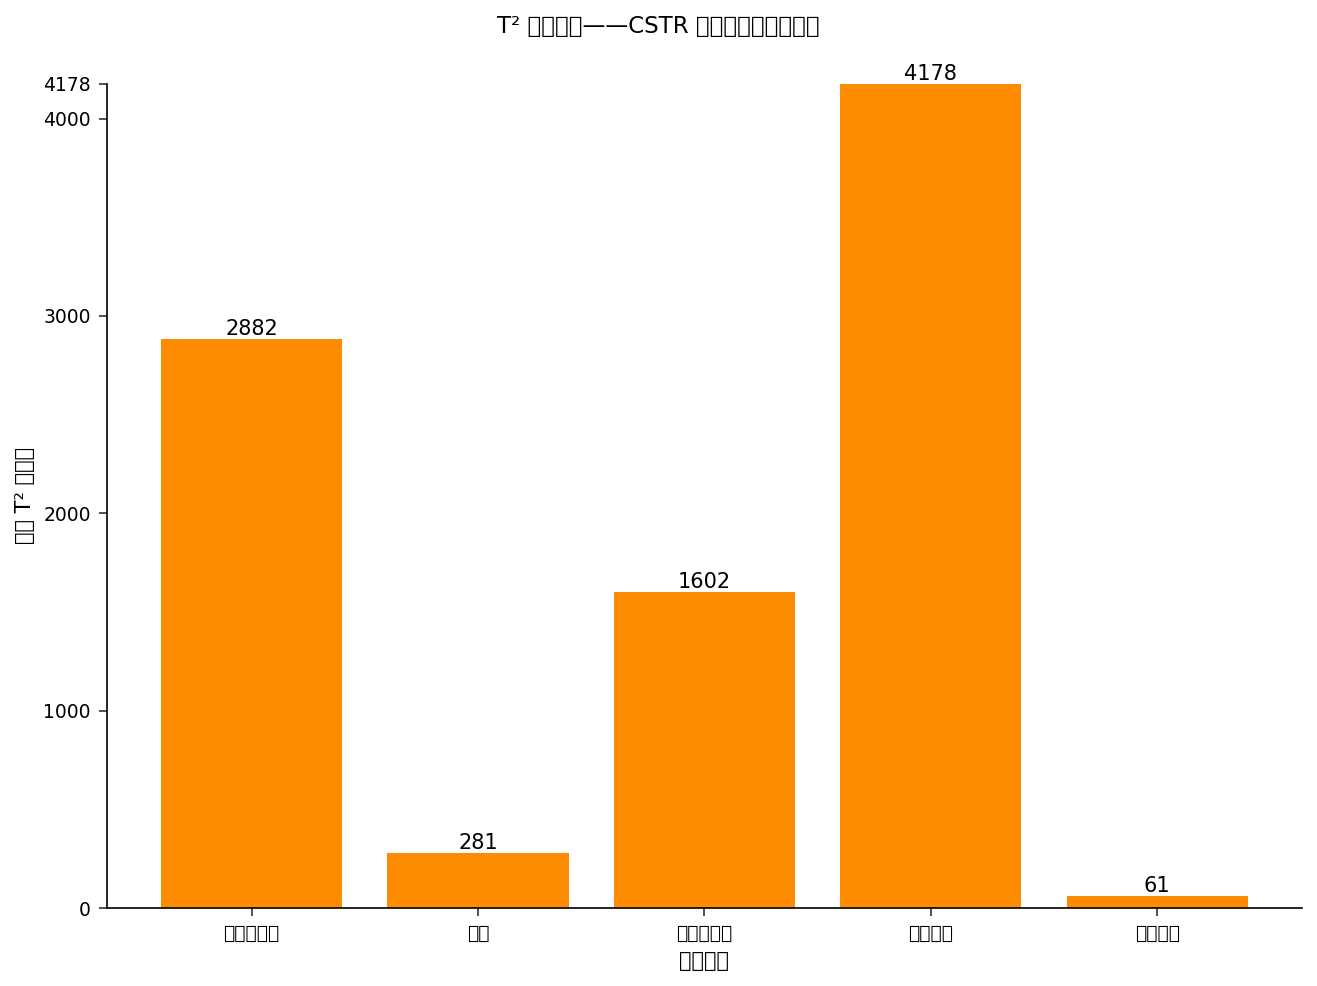

In [4]:
过程 SGPLOT 数据=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS 标签='过程变量';
  YAXIS 标签='平均 T² 贡献度';
  标题 'T² 贡献度图——CSTR 冷却剂失效异常事件';
运行;


## 步骤 5 — *T*² 控制时间线

将每条观测的 *T*² 与模型控制限一同绘制，显示出该异常是连续性的：每一条异常观测都处于远高于限值参考线的量级。在观测窗口内没有出现恢复，这与一个持续存在、直到冷却剂子系统被维修才会消失的硬件故障相符。



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


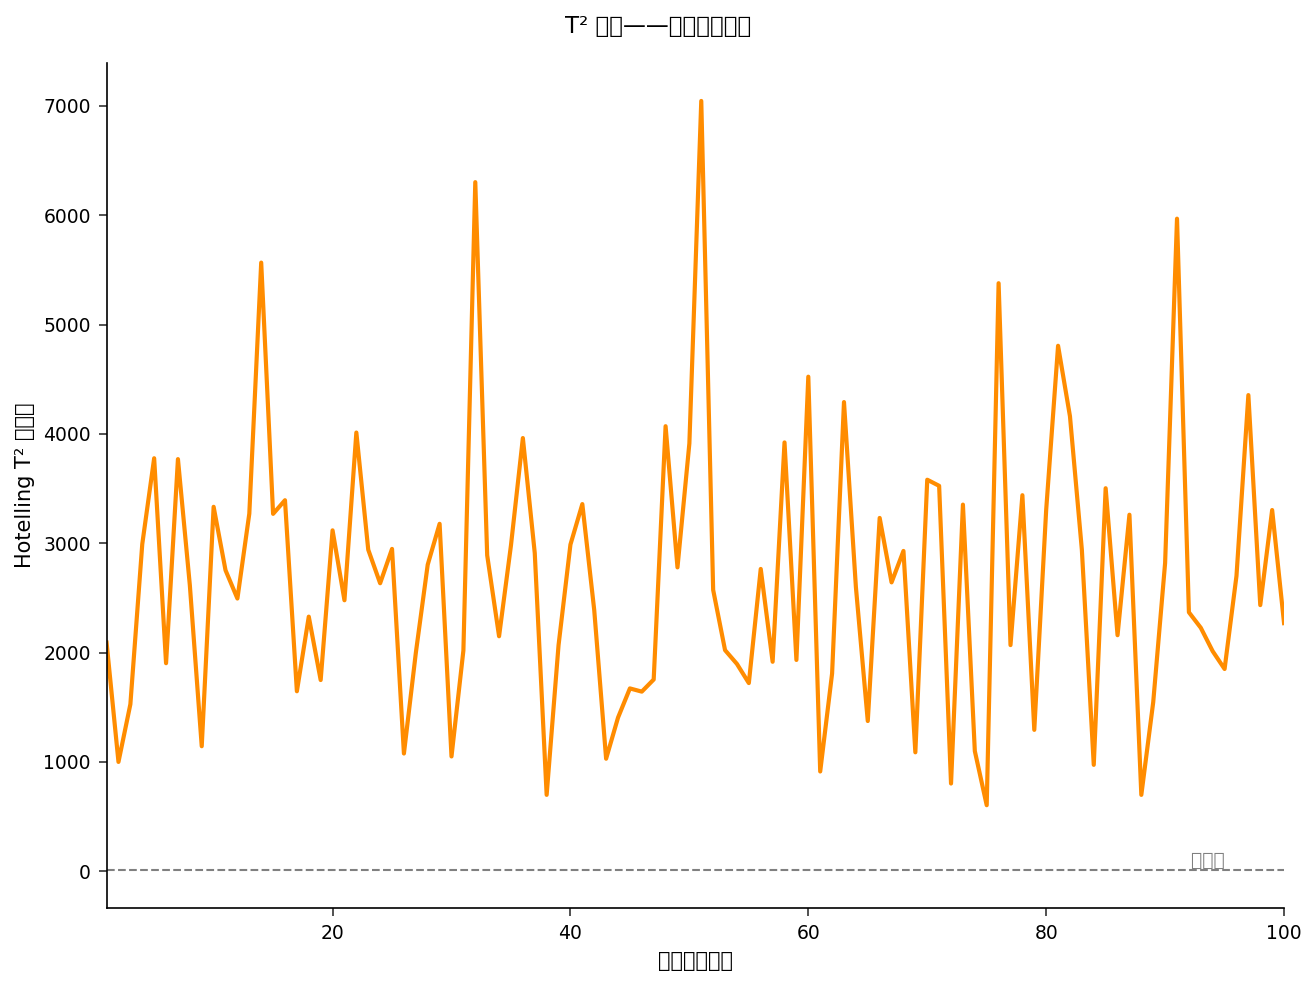

In [5]:
过程 SGPLOT 数据=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  标签='控制限'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS 标签='异常观测序号';
  YAXIS 标签='Hotelling T² 统计量';
  标题 'T² 轨迹——异常事件期间';
运行;


## 结论与整改措施

- **主要驱动因素**：`jacket_temp`、`coolant_flow` 与 `reactor_temp` 三者合计贡献了几乎全部的 *T*² 信号；它们的平均贡献度比 `feed_conc` 与 `pressure` 高出两到三个数量级。
- **根本原因**：冷却剂供应损失。`coolant_flow` 是三者中唯一的*被操纵*变量——温度上升是失去冷却后的下游后果，因此可采取行动的故障点是冷却剂子系统。
- **控制状态**：全部 100 条异常观测均超出 *T*² 限值，表明这是一次持续性异常而非瞬态波动。
- **整改措施**：检查并大修冷却剂泵；增加一台冗余的冷却剂流量变送器，使未来的供应损失能够在传播到温度回路之前，通过单变量报警被及时发现。


## 导出排序后的贡献度

排序后的贡献度表被导出为 CSV，供事后报告和下游看板使用。


In [6]:
过程 EXPORT 数据=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
运行;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持：<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>